# 04 — Supervised Machine Learning v13B

## Sprint 13B.5 — Machine Learning Re-estimation

Objetivo del notebook:

```text
Modelo A = especificación ML v13A
Modelo B = especificación ML v13A + advanced features v13B
```

La finalidad metodológica es aislar el efecto incremental de las nuevas variables avanzadas generadas en Sprint 13B.3:

- `finishing_index_v2`
- `availability_index`
- `defensive_activity_index`

No se modifica el dashboard, el scoring, el Opportunity Score ni la lógica del Transfer Strategy Engine. Este notebook solo valida si las nuevas features aportan señal predictiva adicional en Machine Learning.


## 1. Configuración inicial

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

try:
    from lightgbm import LGBMRegressor
except ImportError as exc:
    raise ImportError(
        "LightGBM no está instalado en este entorno. "
        "Instálalo antes de ejecutar Sprint 13B.5: pip install lightgbm"
    ) from exc

try:
    from xgboost import XGBRegressor
except ImportError as exc:
    raise ImportError(
        "XGBoost no está instalado en este entorno. "
        "Instálalo antes de ejecutar Sprint 13B.5: pip install xgboost"
    ) from exc

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "player_season_modeling_v13b_productive_candidate.parquet"

EXPERIMENT_NAME = "sprint_13b5_ml_advanced_features"

OUTPUT_DIR = PROJECT_ROOT / "reports" / "sprint_13b" / "productive"
FIGURES_DIR = OUTPUT_DIR / "figures"
MODELS_DIR = OUTPUT_DIR / "models"
PREDICTIONS_DIR = OUTPUT_DIR / "predictions"

for path in [OUTPUT_DIR, FIGURES_DIR, MODELS_DIR, PREDICTIONS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"

TARGET = "log_market_value_eur"

print("Current working dir:", Path.cwd())
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())
print("Output dir:", OUTPUT_DIR)


Current working dir: c:\Users\manue\Projects\market-value-football-tfm\notebooks
Project root: C:\Users\manue\Projects\market-value-football-tfm
Dataset path: C:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling_v13b_productive_candidate.parquet
Dataset exists: True
Output dir: C:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\productive


## 2. Carga del dataset v13B advanced

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"No existe el dataset requerido para Sprint 13B.5: {DATA_PATH}\n"
        "Ejecuta primero Sprint 13B.3 Feature Engineering para generar "
        "data/processed/player_season_modeling_v13b_productive_candidate.parquet."
    )

df = pd.read_parquet(DATA_PATH)

print("Dataset cargado")
print(f"Rows: {len(df):,}")
if "player_id_tm" in df.columns:
    print(f"Players: {df['player_id_tm'].nunique():,}")
print(f"Leagues: {df['league'].nunique():,}" if "league" in df.columns else "Leagues: column not found")
print(f"Seasons: {df['season'].nunique():,}" if "season" in df.columns else "Seasons: column not found")

if "league" in df.columns:
    print(sorted(df["league"].dropna().unique()))

display(df.head())


Dataset cargado
Rows: 5,527
Players: 2,867
Leagues: 11
Seasons: 7
['Austrian Bundesliga', 'Belgian Pro League', 'Bundesliga', 'Championship', 'Eredivisie', 'LaLiga', 'Liga Portugal', 'Ligue 1', 'Premier League', 'Serie A', 'Spanish Segunda División']


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age,player_name_normalized,adv_goals,adv_shots,adv_shots_on_target,adv_shots_per90,adv_shots_on_target_per90,adv_minutes,adv_starts,adv_complete_matches,adv_interceptions,adv_tackles_won,goals_position_pct,shots_position_pct,shots_on_target_position_pct,shots_per90_position_pct,shots_on_target_per90_position_pct,starts_position_pct,minutes_position_pct,complete_matches_position_pct,interceptions_position_pct,tackles_won_position_pct,finishing_index_v2,availability_index,defensive_activity_index
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000,marvin young,0,10,1,0.3000,0.0300,2970,33,33,55,39,0.2424,0.4394,0.2576,0.0909,0.1970,0.9091,0.9394,0.9697,0.9394,0.9091,0.2652,0.9364,0.9242
1,Tyrese Campbell,Stoke City,Championship,2022-2023,2022,"FW,MF",MID,22.0000,41,30,2656,29.5000,9,5,14,9,0,0,4,0,0.3000,0.1700,0.4700,0.3000,0.4700,tyrese campbell,"382,554.0000",Tyrese Campbell,"2,022.0000",2022-09-14,"3,000,000.0000",14.9141,"4,000,000.0000","3,000,000.0000",0.0000,0.0000,22.7132,1999-12-28 00:00:00,England,Attack,Centre-Forward,left,185.0000,Stoke City,512.0000,GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.7132,100.0000,True,2022,22.7132,tyrese campbell,9,83,38,2.8100,1.2900,2656,30,15,16,12,0.9123,0.9386,0.9123,0.8421,0.8947,0.7807,0.8772,0.7544,0.6404,0.3596,0.9088,0.8018,0.5000
2,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731,joshua kitolano,4,37,14,1.2600,0.4800,2651,29,25,27,35,0.7453,0.7170,0.6698,0.2358,0.3019,0.8302,0.9245,0.9340,0.8868,0.9245,0.6292,0.8896,0.9057
3,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372,teden mengi,1,11,4,0.4000,0.1500,2469,28,25,54,22,0.6129,0.6452,0.6290,0.3548,0.5000,0.8226,0.8710,0.8710,1.0000,0.5000,0.5855,0.8516,0.7500
4,Harry Clarke,Ipswich Town,Championship,2023-2024,2023,DF,DEF,22.0000,35,25,2361,26.2000,1,1,2,1,0,0,7,0,0.0400,0.0400,0.0800,0.0400,0.0800,harry clarke,"528,892.0000",Harry Clarke,"2,023.0000",2023-12-21,"2,500,000

## 3. Validaciones mínimas de calidad

In [3]:
df = df.copy()

if "season_start_year" not in df.columns:
    if "season" in df.columns:
        df["season_start_year"] = df["season"].astype(str).str[:4].astype(int)
    else:
        raise KeyError("No existe ni season_start_year ni season. No se puede hacer split temporal.")

required_cols = [TARGET, "market_value_eur", "season_start_year", "season"]
missing_required = [c for c in required_cols if c not in df.columns]
if missing_required:
    raise KeyError(f"Faltan columnas obligatorias: {missing_required}")

ADVANCED_FEATURES = [
    "finishing_index_v2",
    "availability_index",
    "defensive_activity_index",
]

missing_advanced = [c for c in ADVANCED_FEATURES if c not in df.columns]
if missing_advanced:
    raise KeyError(
        f"Faltan advanced features necesarias para Sprint 13B.5: {missing_advanced}. "
        "Revisa la salida de Sprint 13B.3."
    )

print("Validación básica completada")
print(df[["season", "season_start_year", TARGET, "market_value_eur", *ADVANCED_FEATURES]].head())

advanced_coverage = (
    df[ADVANCED_FEATURES]
    .notna()
    .mean()
    .rename("coverage")
    .reset_index()
    .rename(columns={"index": "feature"})
)
advanced_coverage["coverage_pct"] = advanced_coverage["coverage"] * 100
display(advanced_coverage)
advanced_coverage.to_csv(OUTPUT_DIR / "advanced_features_coverage_v13b.csv", index=False)


Validación básica completada
      season  season_start_year  log_market_value_eur  market_value_eur  \
0  2025-2026               2025               15.2018    4,000,000.0000   
1  2022-2023               2022               14.9141    3,000,000.0000   
2  2022-2023               2022               13.9978    1,200,000.0000   
3  2023-2024               2023               15.7614    7,000,000.0000   
4  2023-2024               2023               14.7318    2,500,000.0000   

   finishing_index_v2  availability_index  defensive_activity_index  
0              0.2652              0.9364                    0.9242  
1              0.9088              0.8018                    0.5000  
2              0.6292              0.8896                    0.9057  
3              0.5855              0.8516                    0.7500  
4              0.6583              0.7188                    0.5938  


,feature,coverage,coverage_pct
0,finishing_index_v2,0.9843,98.4259
1,availability_index,0.9991,99.9095
2,defensive_activity_index,0.9843,98.4259


## 4. Split temporal

In [4]:
train = df[df["season"].isin(TRAIN_SEASONS)].copy()
test = df[df["season"] == TEST_SEASON].copy()
current_scouting = df[df["season"] == CURRENT_SCOUTING_SEASON].copy()

print("Split temporal")
print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("\nTrain seasons:")
print(train["season"].value_counts().sort_index())
print("\nTest seasons:")
print(test["season"].value_counts().sort_index())
print("\nCurrent scouting season:")
print(current_scouting["season"].value_counts().sort_index())

if len(train) == 0 or len(test) == 0:
    raise ValueError("Train o test están vacíos. Revisar etiquetas de temporada.")

if train[TARGET].isna().any() or test[TARGET].isna().any():
    raise ValueError(f"El target {TARGET} contiene nulos en train o test.")


Split temporal
Train rows: 3,940
Test rows: 776
Current scouting rows: 811

Train seasons:
season
2019-2020    781
2020-2021    760
2021-2022    790
2022-2023    763
2023-2024    846
Name: count, dtype: int64

Test seasons:
season
2024-2025    776
Name: count, dtype: int64

Current scouting season:
season
2025-2026    811
Name: count, dtype: int64


## 5. Definición de feature sets A/B

El experimento mantiene constante la especificación v13A para el Modelo A y añade exclusivamente las tres variables avanzadas en el Modelo B.

Esto permite aislar el efecto incremental de Sprint 13B.3 sin introducir confusión por cambios de algoritmos, hiperparámetros o target.


In [5]:
# Modelo A — especificación ML v13A.
# Se mantiene la lista base del notebook 04_supervised_machine_learning_v13a1.ipynb.
MODEL_A_NUMERIC_CANDIDATES = [
    "age",
    "minutes_played",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
    "g_a_per90",
    "shots_per90",
    "progressive_passes_per90",
    "progressive_carries_per90",
    "tackles_per90",
    "interceptions_per90",
    "finishing_index",
    "playmaking_index",
    "progression_index",
    "defensive_index",
]

# Variables avanzadas Sprint 13B.3.
ADVANCED_FEATURES = [
    "finishing_index_v2",
    "availability_index",
    "defensive_activity_index",
]

# Crear log_minutes_played si no existe.
for dataset in [train, test, current_scouting]:
    if "log_minutes_played" not in dataset.columns and "minutes_played" in dataset.columns:
        dataset["log_minutes_played"] = np.log1p(dataset["minutes_played"])

MODEL_A_NUMERIC_FEATURES = [c for c in MODEL_A_NUMERIC_CANDIDATES if c in train.columns]
MODEL_B_NUMERIC_FEATURES = MODEL_A_NUMERIC_FEATURES + ADVANCED_FEATURES

categorical_candidates = [
    "league",
    "position_group",
]

CATEGORICAL_FEATURES = [c for c in categorical_candidates if c in train.columns]

missing_model_a = [c for c in MODEL_A_NUMERIC_CANDIDATES if c not in train.columns]
if missing_model_a:
    print("Aviso: features v13A candidatas no disponibles en el dataset y excluidas:")
    print(missing_model_a)

if len(MODEL_A_NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES) == 0:
    raise ValueError("No hay features disponibles para entrenar modelos.")

FEATURE_SETS = {
    "A_v13A_current": {
        "numeric_features": MODEL_A_NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
    },
    "B_v13B_advanced": {
        "numeric_features": MODEL_B_NUMERIC_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
    },
}

print("Modelo A — numeric features:")
print(MODEL_A_NUMERIC_FEATURES)
print("\nModelo B — numeric features:")
print(MODEL_B_NUMERIC_FEATURES)
print("\nCategorical features:")
print(CATEGORICAL_FEATURES)

feature_set_summary = pd.DataFrame([
    {
        "feature_set": feature_set,
        "n_numeric_features": len(spec["numeric_features"]),
        "n_categorical_features": len(spec["categorical_features"]),
        "numeric_features": ", ".join(spec["numeric_features"]),
        "categorical_features": ", ".join(spec["categorical_features"]),
    }
    for feature_set, spec in FEATURE_SETS.items()
])
feature_set_summary.to_csv(OUTPUT_DIR / "feature_sets_v13b.csv", index=False)
display(feature_set_summary)


Aviso: features v13A candidatas no disponibles en el dataset y excluidas:
['shots_per90', 'progressive_passes_per90', 'progressive_carries_per90', 'tackles_per90', 'interceptions_per90', 'finishing_index', 'playmaking_index', 'progression_index', 'defensive_index']
Modelo A — numeric features:
['age', 'minutes_played', 'log_minutes_played', 'goals_per90', 'assists_per90', 'g_a_per90']

Modelo B — numeric features:
['age', 'minutes_played', 'log_minutes_played', 'goals_per90', 'assists_per90', 'g_a_per90', 'finishing_index_v2', 'availability_index', 'defensive_activity_index']

Categorical features:
['league', 'position_group']


,feature_set,n_numeric_features,n_categorical_features,numeric_features,categorical_features
0,A_v13A_current,6,2,"age, minutes_played, log_minutes_played, goals...","league, position_group"
1,B_v13B_advanced,9,2,"age, minutes_played, log_minutes_played, goals...","league, position_group"


## 6. Funciones auxiliares

In [6]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ],
        remainder="drop",
    )


def regression_metrics(y_true, y_pred, model, feature_set, split):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    return {
        "model": model,
        "feature_set": feature_set,
        "split": split,
        "MAE_log": mae,
        "RMSE_log": rmse,
        "R2": r2,
        "RMSE_multiplicative_factor": np.exp(rmse),
    }


def get_feature_names_from_pipeline(pipe, numeric_features, categorical_features):
    preprocessor = pipe.named_steps["preprocessor"]
    feature_names = []

    if numeric_features:
        feature_names.extend([f"num__{c}" for c in numeric_features])

    if categorical_features:
        cat_pipeline = preprocessor.named_transformers_["cat"]
        onehot = cat_pipeline.named_steps["onehot"]
        try:
            cat_names = onehot.get_feature_names_out(categorical_features)
        except TypeError:
            cat_names = onehot.get_feature_names(categorical_features)
        feature_names.extend([f"cat__{c}" for c in cat_names])

    return np.array(feature_names)


def clean_feature_name(feature_name):
    if feature_name.startswith("num__"):
        return feature_name.replace("num__", "", 1)
    if feature_name.startswith("cat__"):
        return feature_name.replace("cat__", "", 1)
    return feature_name


def extract_tree_importance(pipe, model_name, feature_set, numeric_features, categorical_features):
    model = pipe.named_steps["model"]
    if not hasattr(model, "feature_importances_"):
        return pd.DataFrame()

    feature_names = get_feature_names_from_pipeline(pipe, numeric_features, categorical_features)
    importances = np.asarray(model.feature_importances_)

    if len(feature_names) != len(importances):
        raise ValueError(
            f"Longitud incompatible en feature importance para {model_name} / {feature_set}: "
            f"{len(feature_names)} nombres vs {len(importances)} importancias."
        )

    out = pd.DataFrame({
        "model": model_name,
        "feature_set": feature_set,
        "transformed_feature": feature_names,
        "feature": [clean_feature_name(f) for f in feature_names],
        "importance": importances,
    })

    out = out.sort_values("importance", ascending=False).reset_index(drop=True)
    out["rank"] = np.arange(1, len(out) + 1)
    return out


def aggregate_importance_to_original_features(importance_df):
    if importance_df.empty:
        return importance_df

    # Para variables categóricas one-hot, agregamos por variable original aproximada.
    def original_feature(feature):
        for cat in CATEGORICAL_FEATURES:
            if feature.startswith(f"{cat}_"):
                return cat
        return feature

    out = importance_df.copy()
    out["original_feature"] = out["feature"].map(original_feature)

    agg = (
        out.groupby(["model", "feature_set", "original_feature"], as_index=False)
        .agg(
            importance=("importance", "sum"),
            max_component_importance=("importance", "max"),
            n_components=("feature", "count"),
        )
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    agg["rank"] = np.arange(1, len(agg) + 1)
    return agg


## 7. Definición de algoritmos

Se reentrenan exactamente las familias indicadas para Sprint 13B.5:

- Random Forest
- HistGradientBoosting
- LightGBM
- XGBoost

No se añaden nuevos algoritmos.


In [7]:
def build_models():
    return {
        "RandomForest": RandomForestRegressor(
            n_estimators=500,
            max_depth=8,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "HistGradientBoosting": HistGradientBoostingRegressor(
            max_iter=300,
            learning_rate=0.03,
            max_leaf_nodes=31,
            min_samples_leaf=15,
            l2_regularization=0.05,
            random_state=RANDOM_STATE,
        ),
        "LightGBM": LGBMRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=-1,
            num_leaves=31,
            min_child_samples=15,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=0.05,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        ),
        "XGBoost": XGBRegressor(
            n_estimators=500,
            learning_rate=0.03,
            max_depth=4,
            min_child_weight=5,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective="reg:squarederror",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
    }


models = build_models()
list(models.keys())


['RandomForest', 'HistGradientBoosting', 'LightGBM', 'XGBoost']

## 8. Entrenamiento y evaluación A/B

In [8]:
results = []
fitted_models = {}
predictions = {}

for feature_set, spec in FEATURE_SETS.items():
    numeric_features = spec["numeric_features"]
    categorical_features = spec["categorical_features"]

    selected_features = numeric_features + categorical_features

    X_train = train[selected_features].copy()
    X_test = test[selected_features].copy()
    y_train = train[TARGET].copy()
    y_test = test[TARGET].copy()

    print("\n" + "=" * 90)
    print(f"Feature set: {feature_set}")
    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
    print("=" * 90)

    for model_name, model in build_models().items():
        print(f"Training {model_name} — {feature_set}...")

        preprocessor = build_preprocessor(numeric_features, categorical_features)
        pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

        pipe.fit(X_train, y_train)

        pred_train = pipe.predict(X_train)
        pred_test = pipe.predict(X_test)

        fitted_models[(model_name, feature_set)] = pipe
        predictions[(model_name, feature_set)] = {
            "train": pred_train,
            "test": pred_test,
        }

        results.append(regression_metrics(y_train, pred_train, model_name, feature_set, "train"))
        results.append(regression_metrics(y_test, pred_test, model_name, feature_set, "test"))

metrics_df = pd.DataFrame(results).sort_values(["model", "feature_set", "split"])
display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / "ml_model_comparison_raw_v13b.csv", index=False)



Feature set: A_v13A_current
X_train: (3940, 8) | X_test: (776, 8)
Training RandomForest — A_v13A_current...
Training HistGradientBoosting — A_v13A_current...
Training LightGBM — A_v13A_current...
Training XGBoost — A_v13A_current...

Feature set: B_v13B_advanced
X_train: (3940, 11) | X_test: (776, 11)
Training RandomForest — B_v13B_advanced...
Training HistGradientBoosting — B_v13B_advanced...
Training LightGBM — B_v13B_advanced...
Training XGBoost — B_v13B_advanced...


,model,feature_set,split,MAE_log,RMSE_log,R2,RMSE_multiplicative_factor
3,HistGradientBoosting,A_v13A_current,test,0.7904,0.9867,0.4187,2.6825
2,HistGradientBoosting,A_v13A_current,train,0.6142,0.7607,0.6513,2.1399
11,HistGradientBoosting,B_v13B_advanced,test,0.7818,0.9745,0.4331,2.6498
10,HistGradientBoosting,B_v13B_advanced,train,0.5801,0.7174,0.6899,2.0492
5,LightGBM,A_v13A_current,test,0.8023,1.0049,0.3971,2.7316
4,LightGBM,A_v13A_current,train,0.5513,0.6864,0.7161,1.9866
13,LightGBM,B_v13B_advanced,test,0.7830,0.9803,0.4262,2.6653
12,LightGBM,B_v13B_advanced,train,0.4979,0.6244,0.7651,1.8671
1,RandomForest,A_v13A_current,test,0.8043,0.9888,0.4162,2.6881
0,RandomForest,A_v13A_current,train,0.7376,0.9032,0.5084,2.4676


## 9. Comparación incremental A vs B

In [9]:
comparison_rows = []

for model_name in sorted(metrics_df["model"].unique()):
    for split in ["train", "test"]:
        model_split = metrics_df[(metrics_df["model"] == model_name) & (metrics_df["split"] == split)].copy()

        a = model_split[model_split["feature_set"] == "A_v13A_current"]
        b = model_split[model_split["feature_set"] == "B_v13B_advanced"]

        if len(a) != 1 or len(b) != 1:
            raise ValueError(f"No se puede calcular delta para {model_name} / {split}")

        a = a.iloc[0]
        b = b.iloc[0]

        comparison_rows.append({
            "model": model_name,
            "split": split,
            "feature_set_A": "A_v13A_current",
            "feature_set_B": "B_v13B_advanced",
            "MAE_A": a["MAE_log"],
            "MAE_B": b["MAE_log"],
            "RMSE_A": a["RMSE_log"],
            "RMSE_B": b["RMSE_log"],
            "R2_A": a["R2"],
            "R2_B": b["R2"],
            "delta_MAE_B_minus_A": b["MAE_log"] - a["MAE_log"],
            "delta_RMSE_B_minus_A": b["RMSE_log"] - a["RMSE_log"],
            "delta_R2_B_minus_A": b["R2"] - a["R2"],
            "MAE_improves": b["MAE_log"] < a["MAE_log"],
            "RMSE_improves": b["RMSE_log"] < a["RMSE_log"],
            "R2_improves": b["R2"] > a["R2"],
        })

comparison_ab = pd.DataFrame(comparison_rows).sort_values(["split", "delta_RMSE_B_minus_A"])

# Tabla principal solicitada. Incluye métricas train/test y deltas B - A.
comparison_ab.to_csv(OUTPUT_DIR / "ml_model_comparison_v13b.csv", index=False)

comparison_test = comparison_ab[comparison_ab["split"] == "test"].copy()
comparison_test.to_csv(OUTPUT_DIR / "ml_model_comparison_test_v13b.csv", index=False)

display(comparison_ab)
display(comparison_test)


,model,split,feature_set_A,feature_set_B,MAE_A,MAE_B,RMSE_A,RMSE_B,R2_A,R2_B,delta_MAE_B_minus_A,delta_RMSE_B_minus_A,delta_R2_B_minus_A,MAE_improves,RMSE_improves,R2_improves
3,LightGBM,test,A_v13A_current,B_v13B_advanced,0.8023,0.7830,1.0049,0.9803,0.3971,0.4262,-0.0193,-0.0245,0.0291,True,True,True
1,HistGradientBoosting,test,A_v13A_current,B_v13B_advanced,0.7904,0.7818,0.9867,0.9745,0.4187,0.4331,-0.0086,-0.0123,0.0144,True,True,True
7,XGBoost,test,A_v13A_current,B_v13B_advanced,0.7852,0.7777,0.9722,0.9639,0.4357,0.4453,-0.0075,-0.0083,0.0096,True,True,True
5,RandomForest,test,A_v13A_current,B_v13B_advanced,0.8043,0.8034,0.9888,0.9806,0.4162,0.4260,-0.0008,-0.0083,0.0097,True,True,True
2,LightGBM,train,A_v13A_current,B_v13B_advanced,0.5513,0.4979,0.6864,0.6244,0.7161,0.7651,-0.0533,-0.0620,0.0490,True,True,True
0,HistGradientBoosting,train,A_v13A_current,B_v13B_advanced,0.6142,0.5801,0.7607,0.7174,0.6513,0.6899,-0.0341,-0.0433,0.0386,True,True,True
6,XGBoost,train,A_v13A_current,B_v13B_advanced,0.6669,0.6409,0.8231,0.7917,0.5918,0.6224,-0.0261,-0.0315,0.0306,True,True,True
4,RandomForest,train,A_v13A_current,B_v13B_advanced,0.7376,0.7278,0.9032,0.8914,0.5084,0.5212,-0.0097,-0.0118,0.0128,True,True,True


,model,split,feature_set_A,feature_set_B,MAE_A,MAE_B,RMSE_A,RMSE_B,R2_A,R2_B,delta_MAE_B_minus_A,delta_RMSE_B_minus_A,delta_R2_B_minus_A,MAE_improves,RMSE_improves,R2_improves
3,LightGBM,test,A_v13A_current,B_v13B_advanced,0.8023,0.7830,1.0049,0.9803,0.3971,0.4262,-0.0193,-0.0245,0.0291,True,True,True
1,HistGradientBoosting,test,A_v13A_current,B_v13B_advanced,0.7904,0.7818,0.9867,0.9745,0.4187,0.4331,-0.0086,-0.0123,0.0144,True,True,True
7,XGBoost,test,A_v13A_current,B_v13B_advanced,0.7852,0.7777,0.9722,0.9639,0.4357,0.4453,-0.0075,-0.0083,0.0096,True,True,True
5,RandomForest,test,A_v13A_current,B_v13B_advanced,0.8043,0.8034,0.9888,0.9806,0.4162,0.4260,-0.0008,-0.0083,0.0097,True,True,True


## 10. Resumen de criterios de éxito

In [10]:
success_rows = []

for _, row in comparison_test.iterrows():
    success_rows.append({
        "model": row["model"],
        "xgboost_improves": bool(row["model"] == "XGBoost" and (
            row["R2_improves"] or row["RMSE_improves"] or row["MAE_improves"]
        )),
        "lightgbm_improves": bool(row["model"] == "LightGBM" and (
            row["R2_improves"] or row["RMSE_improves"] or row["MAE_improves"]
        )),
        "r2_improves": bool(row["R2_improves"]),
        "rmse_improves": bool(row["RMSE_improves"]),
        "mae_improves": bool(row["MAE_improves"]),
    })

success_df = pd.DataFrame(success_rows)
success_criteria = {
    "xgboost_improves": bool(success_df["xgboost_improves"].any()),
    "lightgbm_improves": bool(success_df["lightgbm_improves"].any()),
    "any_r2_improves": bool(success_df["r2_improves"].any()),
    "any_rmse_improves": bool(success_df["rmse_improves"].any()),
    "any_mae_improves": bool(success_df["mae_improves"].any()),
}

success_summary = pd.DataFrame([
    {"criterion": criterion, "satisfied": satisfied}
    for criterion, satisfied in success_criteria.items()
])

success_summary["sprint_13b5_success"] = success_summary["satisfied"].any()

display(success_summary)
success_summary.to_csv(OUTPUT_DIR / "ml_success_criteria_v13b.csv", index=False)


,criterion,satisfied,sprint_13b5_success
0,xgboost_improves,True,True
1,lightgbm_improves,True,True
2,any_r2_improves,True,True
3,any_rmse_improves,True,True
4,any_mae_improves,True,True


## 11. Feature importance — modelos con importancia nativa

In [11]:
importance_frames = []
importance_agg_frames = []

for model_name in ["RandomForest", "LightGBM", "XGBoost"]:
    key = (model_name, "B_v13B_advanced")
    if key not in fitted_models:
        raise KeyError(f"No existe modelo entrenado: {key}")

    spec = FEATURE_SETS["B_v13B_advanced"]
    imp = extract_tree_importance(
        pipe=fitted_models[key],
        model_name=model_name,
        feature_set="B_v13B_advanced",
        numeric_features=spec["numeric_features"],
        categorical_features=spec["categorical_features"],
    )

    if imp.empty:
        print(f"{model_name} no expone feature_importances_.")
        continue

    imp_agg = aggregate_importance_to_original_features(imp)

    importance_frames.append(imp)
    importance_agg_frames.append(imp_agg)

    filename_map = {
        "RandomForest": "feature_importance_rf_v13b.csv",
        "LightGBM": "feature_importance_lightgbm_v13b.csv",
        "XGBoost": "feature_importance_xgboost_v13b.csv",
    }

    imp_agg.to_csv(OUTPUT_DIR / filename_map[model_name], index=False)

all_importance = pd.concat(importance_frames, ignore_index=True) if importance_frames else pd.DataFrame()
all_importance_agg = pd.concat(importance_agg_frames, ignore_index=True) if importance_agg_frames else pd.DataFrame()

all_importance.to_csv(OUTPUT_DIR / "feature_importance_all_transformed_v13b.csv", index=False)
all_importance_agg.to_csv(OUTPUT_DIR / "feature_importance_all_aggregated_v13b.csv", index=False)

display(all_importance_agg.head(30))


,model,feature_set,original_feature,importance,max_component_importance,n_components,rank
0,RandomForest,B_v13B_advanced,league,0.5843,0.2334,11,1
1,RandomForest,B_v13B_advanced,finishing_index_v2,0.1156,0.1156,1,2
2,RandomForest,B_v13B_advanced,g_a_per90,0.0733,0.0733,1,3
3,RandomForest,B_v13B_advanced,availability_index,0.0671,0.0671,1,4
4,RandomForest,B_v13B_advanced,minutes_played,0.0320,0.0320,1,5
5,RandomForest,B_v13B_advanced,assists_per90,0.0316,0.0316,1,6
6,RandomForest,B_v13B_advanced,log_minutes_played,0.0312,0.0312,1,7
7,RandomForest,B_v13B_advanced,age,0.0305,0.0305,1,8
8,RandomForest,B_v13B_advanced,defensive_activity_index,0.0151,0.0151,1,9
9,RandomForest,B_v13B_advanced,goals_per90,0.0145,0.0145,1,10


## 12. Presencia de advanced features en Top-15

In [12]:
advanced_importance_rows = []

for model_name in ["RandomForest", "LightGBM", "XGBoost"]:
    model_imp = all_importance_agg[
        (all_importance_agg["model"] == model_name)
        & (all_importance_agg["feature_set"] == "B_v13B_advanced")
    ].copy()

    for feature in ADVANCED_FEATURES:
        feature_row = model_imp[model_imp["original_feature"] == feature]
        if len(feature_row) == 0:
            advanced_importance_rows.append({
                "model": model_name,
                "advanced_feature": feature,
                "importance": 0.0,
                "rank": np.nan,
                "top_15": False,
                "top_10": False,
            })
        else:
            feature_row = feature_row.iloc[0]
            advanced_importance_rows.append({
                "model": model_name,
                "advanced_feature": feature,
                "importance": feature_row["importance"],
                "rank": int(feature_row["rank"]),
                "top_15": bool(feature_row["rank"] <= 15),
                "top_10": bool(feature_row["rank"] <= 10),
            })

advanced_importance_summary = (
    pd.DataFrame(advanced_importance_rows)
    .sort_values(["model", "rank"], na_position="last")
    .reset_index(drop=True)
)

display(advanced_importance_summary)
advanced_importance_summary.to_csv(OUTPUT_DIR / "advanced_features_importance_summary_v13b.csv", index=False)

top15_success = bool(advanced_importance_summary["top_15"].any())
print(f"¿Alguna advanced feature entra en Top-15 importance? {top15_success}")


,model,advanced_feature,importance,rank,top_15,top_10
0,LightGBM,availability_index,"1,982.0000",2,True,True
1,LightGBM,defensive_activity_index,"1,927.0000",3,True,True
2,LightGBM,finishing_index_v2,"1,900.0000",4,True,True
3,RandomForest,finishing_index_v2,0.1156,2,True,True
4,RandomForest,availability_index,0.0671,4,True,True
5,RandomForest,defensive_activity_index,0.0151,9,True,True
6,XGBoost,finishing_index_v2,0.0226,4,True,True
7,XGBoost,availability_index,0.0172,7,True,True
8,XGBoost,defensive_activity_index,0.0092,11,True,False


¿Alguna advanced feature entra en Top-15 importance? True


## 13. Ranking de contribución de nuevas variables

In [13]:
# Ranking agregado de contribución mediante importancia media normalizada en RF, LightGBM y XGBoost.
ranking_df = advanced_importance_summary.copy()

# Normalización por modelo para evitar que escalas de importance distintas dominen el promedio.
ranking_df["importance_normalized_by_model"] = ranking_df.groupby("model")["importance"].transform(
    lambda s: s / s.sum() if s.sum() > 0 else 0.0
)

advanced_feature_ranking = (
    ranking_df.groupby("advanced_feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        mean_normalized_importance=("importance_normalized_by_model", "mean"),
        best_rank=("rank", "min"),
        models_top_15=("top_15", "sum"),
        models_top_10=("top_10", "sum"),
    )
    .sort_values(
        ["mean_normalized_importance", "models_top_15", "best_rank"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

advanced_feature_ranking["contribution_rank"] = np.arange(1, len(advanced_feature_ranking) + 1)

display(advanced_feature_ranking)
advanced_feature_ranking.to_csv(OUTPUT_DIR / "advanced_features_contribution_ranking_v13b.csv", index=False)


,advanced_feature,mean_importance,mean_normalized_importance,best_rank,models_top_15,models_top_10,contribution_rank
0,finishing_index_v2,633.3794,0.4573,2,3,3,1
1,availability_index,660.6948,0.3439,2,3,3,2
2,defensive_activity_index,642.3414,0.1987,3,3,2,3


## 14. Advanced features performance summary

In [14]:
best_delta_by_r2 = comparison_test.sort_values("delta_R2_B_minus_A", ascending=False).iloc[0]
best_delta_by_rmse = comparison_test.sort_values("delta_RMSE_B_minus_A", ascending=True).iloc[0]
best_delta_by_mae = comparison_test.sort_values("delta_MAE_B_minus_A", ascending=True).iloc[0]

xgboost_row = comparison_test[comparison_test["model"] == "XGBoost"]
lightgbm_row = comparison_test[comparison_test["model"] == "LightGBM"]

summary_records = [
    {
        "item": "best_delta_r2_model",
        "value": best_delta_by_r2["model"],
        "metric": "delta_R2_B_minus_A",
        "numeric_value": best_delta_by_r2["delta_R2_B_minus_A"],
    },
    {
        "item": "best_delta_rmse_model",
        "value": best_delta_by_rmse["model"],
        "metric": "delta_RMSE_B_minus_A",
        "numeric_value": best_delta_by_rmse["delta_RMSE_B_minus_A"],
    },
    {
        "item": "best_delta_mae_model",
        "value": best_delta_by_mae["model"],
        "metric": "delta_MAE_B_minus_A",
        "numeric_value": best_delta_by_mae["delta_MAE_B_minus_A"],
    },
    {
        "item": "any_advanced_feature_top15",
        "value": str(top15_success),
        "metric": "boolean",
        "numeric_value": float(top15_success),
    },
]

if len(xgboost_row) == 1:
    r = xgboost_row.iloc[0]
    summary_records.extend([
        {"item": "xgboost_delta_r2", "value": "XGBoost", "metric": "delta_R2_B_minus_A", "numeric_value": r["delta_R2_B_minus_A"]},
        {"item": "xgboost_delta_rmse", "value": "XGBoost", "metric": "delta_RMSE_B_minus_A", "numeric_value": r["delta_RMSE_B_minus_A"]},
        {"item": "xgboost_delta_mae", "value": "XGBoost", "metric": "delta_MAE_B_minus_A", "numeric_value": r["delta_MAE_B_minus_A"]},
    ])

if len(lightgbm_row) == 1:
    r = lightgbm_row.iloc[0]
    summary_records.extend([
        {"item": "lightgbm_delta_r2", "value": "LightGBM", "metric": "delta_R2_B_minus_A", "numeric_value": r["delta_R2_B_minus_A"]},
        {"item": "lightgbm_delta_rmse", "value": "LightGBM", "metric": "delta_RMSE_B_minus_A", "numeric_value": r["delta_RMSE_B_minus_A"]},
        {"item": "lightgbm_delta_mae", "value": "LightGBM", "metric": "delta_MAE_B_minus_A", "numeric_value": r["delta_MAE_B_minus_A"]},
    ])

if len(advanced_feature_ranking) > 0:
    top_feature = advanced_feature_ranking.iloc[0]
    summary_records.append({
        "item": "top_advanced_feature_by_importance",
        "value": top_feature["advanced_feature"],
        "metric": "mean_normalized_importance",
        "numeric_value": top_feature["mean_normalized_importance"],
    })

advanced_features_performance_summary = pd.DataFrame(summary_records)
advanced_features_performance_summary.to_csv(
    OUTPUT_DIR / "advanced_features_performance_summary.csv",
    index=False,
)

display(advanced_features_performance_summary)


,item,value,metric,numeric_value
0,best_delta_r2_model,LightGBM,delta_R2_B_minus_A,0.0291
1,best_delta_rmse_model,LightGBM,delta_RMSE_B_minus_A,-0.0245
2,best_delta_mae_model,LightGBM,delta_MAE_B_minus_A,-0.0193
3,any_advanced_feature_top15,True,boolean,1.0000
4,xgboost_delta_r2,XGBoost,delta_R2_B_minus_A,0.0096
5,xgboost_delta_rmse,XGBoost,delta_RMSE_B_minus_A,-0.0083
6,xgboost_delta_mae,XGBoost,delta_MAE_B_minus_A,-0.0075
7,lightgbm_delta_r2,LightGBM,delta_R2_B_minus_A,0.0291
8,lightgbm_delta_rmse,LightGBM,delta_RMSE_B_minus_A,-0.0245
9,lightgbm_delta_mae,LightGBM,delta_MAE_B_minus_A,-0.0193


## 15. Visualización de deltas out-of-sample

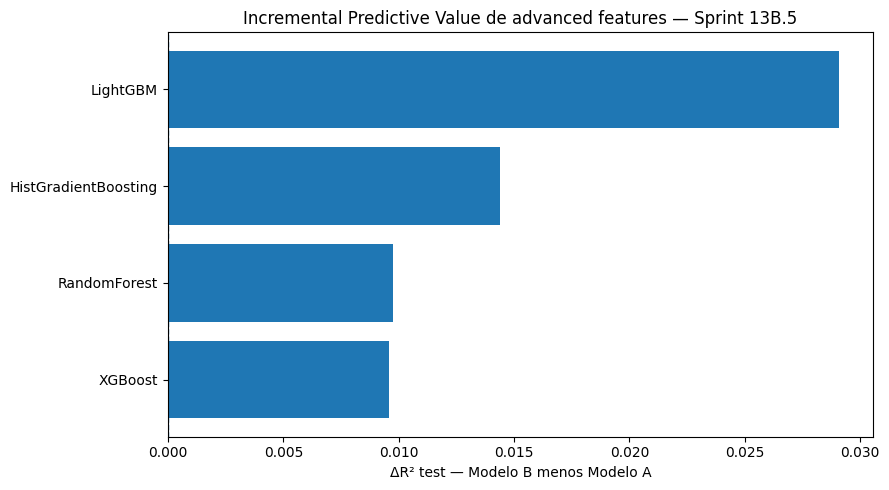

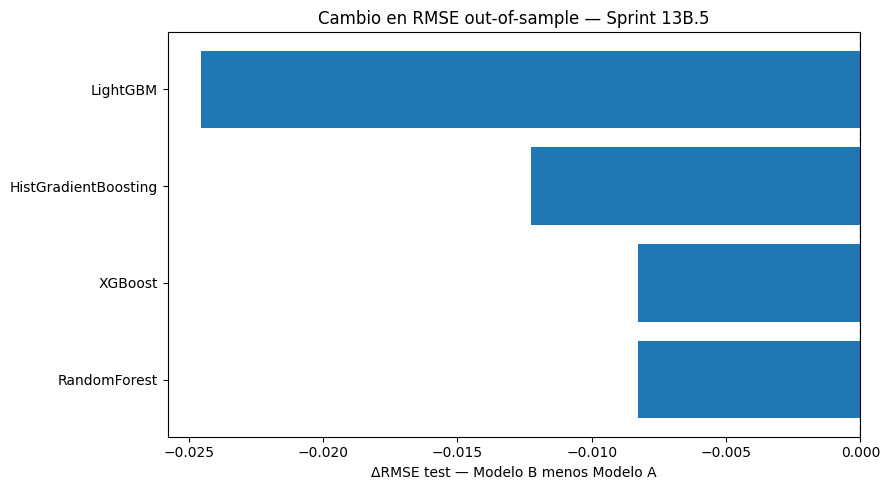

In [15]:
plot_df = comparison_test.sort_values("delta_R2_B_minus_A", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["delta_R2_B_minus_A"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("ΔR² test — Modelo B menos Modelo A")
plt.title("Incremental Predictive Value de advanced features — Sprint 13B.5")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delta_r2_test_v13b.png", dpi=150)
plt.show()

plot_df = comparison_test.sort_values("delta_RMSE_B_minus_A", ascending=False)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["model"], plot_df["delta_RMSE_B_minus_A"])
plt.axvline(0, linestyle="--", linewidth=1)
plt.xlabel("ΔRMSE test — Modelo B menos Modelo A")
plt.title("Cambio en RMSE out-of-sample — Sprint 13B.5")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "delta_rmse_test_v13b.png", dpi=150)
plt.show()


## 16. Exportación de predicciones test A/B

In [16]:
prediction_exports = []

for (model_name, feature_set), preds in predictions.items():
    tmp = test.copy()
    tmp["model"] = model_name
    tmp["feature_set"] = feature_set
    tmp["predicted_log_market_value_ml"] = preds["test"]
    tmp["predicted_market_value_ml_eur"] = np.exp(tmp["predicted_log_market_value_ml"])
    tmp["residual_log_observed_minus_predicted"] = tmp[TARGET] - tmp["predicted_log_market_value_ml"]
    tmp["inefficiency_score_ml"] = tmp["predicted_log_market_value_ml"] - tmp[TARGET]

    prediction_exports.append(tmp)

predictions_test_df = pd.concat(prediction_exports, ignore_index=True)

name_candidates = ["player_name_fbref", "player_name", "player_name_tm"]
name_col = next((c for c in name_candidates if c in predictions_test_df.columns), None)

prediction_cols = [c for c in [
    name_col,
    "player_id_tm",
    "club",
    "current_club_name_tm",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    TARGET,
    "model",
    "feature_set",
    "predicted_log_market_value_ml",
    "predicted_market_value_ml_eur",
    "residual_log_observed_minus_predicted",
    "inefficiency_score_ml",
] if c is not None and c in predictions_test_df.columns]

predictions_test_df[prediction_cols].to_parquet(
    PREDICTIONS_DIR / "04_ml_test_predictions_v13b.parquet",
    index=False,
)
predictions_test_df[prediction_cols].to_csv(
    PREDICTIONS_DIR / "04_ml_test_predictions_v13b.csv",
    index=False,
)

print("Predicciones test exportadas:")
print(PREDICTIONS_DIR / "04_ml_test_predictions_v13b.parquet")
print(PREDICTIONS_DIR / "04_ml_test_predictions_v13b.csv")


Predicciones test exportadas:
C:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\productive\predictions\04_ml_test_predictions_v13b.parquet
C:\Users\manue\Projects\market-value-football-tfm\reports\sprint_13b\productive\predictions\04_ml_test_predictions_v13b.csv


## 17. Checklist de outputs obligatorios

In [17]:
required_outputs = [
    OUTPUT_DIR / "ml_model_comparison_v13b.csv",
    OUTPUT_DIR / "feature_importance_xgboost_v13b.csv",
    OUTPUT_DIR / "feature_importance_lightgbm_v13b.csv",
    OUTPUT_DIR / "feature_importance_rf_v13b.csv",
    OUTPUT_DIR / "advanced_features_performance_summary.csv",
]

output_check = pd.DataFrame([
    {
        "path": str(path.relative_to(PROJECT_ROOT)),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    }
    for path in required_outputs
])

display(output_check)

if not output_check["exists"].all():
    missing = output_check.loc[~output_check["exists"], "path"].tolist()
    raise FileNotFoundError(f"Faltan outputs obligatorios: {missing}")

print("Todos los outputs obligatorios de Sprint 13B.5 han sido generados correctamente.")


,path,exists,size_bytes
0,reports\sprint_13b\productive\ml_model_compari...,True,2121
1,reports\sprint_13b\productive\feature_importan...,True,831
2,reports\sprint_13b\productive\feature_importan...,True,683
3,reports\sprint_13b\productive\feature_importan...,True,1072
4,reports\sprint_13b\productive\advanced_feature...,True,811


Todos los outputs obligatorios de Sprint 13B.5 han sido generados correctamente.


## 18. Interpretación final esperada

Al ejecutar el notebook, la interpretación del Sprint 13B.5 debe responder:

1. ¿Las nuevas variables aportan valor predictivo adicional en Machine Learning?
2. ¿El beneficio incremental es mayor en ML o en la reestimación econométrica de Sprint 13B.4?
3. ¿Qué advanced feature aporta más señal según la importancia agregada?
4. ¿Deben promocionarse `finishing_index_v2`, `availability_index` y `defensive_activity_index` al pipeline productivo?
5. ¿Qué impacto tendría esta decisión sobre la calidad del sistema de scouting?

Criterio de promoción recomendado:

```text
Promoción fuerte:
- XGBoost o LightGBM mejora en test
- y alguna advanced feature entra en Top-15 importance

Promoción parcial:
- mejora en algún modelo pero sin presencia clara en Top-15

No promoción:
- ausencia de mejora out-of-sample y baja relevancia en feature importance
```
